# Real-World AI-Driven Analytics with Python — NYC Taxi Data
## Deliverable 2: Model Optimization, Real-World Impact, and Ethical Evaluation

**Business problem.** Ride-hail apps show riders a price *before* the trip starts, but a yellow or green
NYC taxi fare is only known when the meter stops. Taxi fleets, e-hail apps (e.g. Curb) and the NYC Taxi &
Limousine Commission (TLC) want a reliable **upfront fare estimate** so riders can budget, compare
modes of transport, and trust the price they are quoted.

**Analytics task.** Supervised **regression**: predict the metered `fare` (USD, excluding tip, tolls and
surcharges) from information that is available *at booking time*: route distance, pickup/dropoff
location, time of day, day of week, taxi type, and party size.

**Notebook map**

| Part | Content |
|---|---|
| 0 | Setup and configuration |
| 1 | Recap of Deliverable 1 — data loading, cleaning, feature engineering, EDA, baseline models |
| 2 | Hyperparameter tuning (Ridge, Random Forest, Histogram Gradient Boosting) |
| 3 | Final model evaluation on a time-based hold-out week |
| 4 | Ethical evaluation — error audit across boroughs, taxi type and payment groups |
| 5 | Real-world application — upfront-quote simulation and fare ranges |
| 6 | Final thoughts and conclusion |

Libraries: pandas, NumPy, Matplotlib, Seaborn, scikit-learn (Dask optional for the full TLC files).

## Part 0 — Setup and configuration

In [1]:
import warnings, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import loguniform, randint, uniform
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, RandomizedSearchCV, cross_validate, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)

# --- Data source -------------------------------------------------------------------------------
# "sample": 6,433 real TLC trips (yellow + green, March 2019) redistributed by the seaborn project.
#           Small enough to tune many models in minutes; this is the run reported in REPORT.md.
# "tlc":    the official TLC trip-record parquet files for TLC_MONTH (millions of rows), randomly
#           sampled down to TLC_SAMPLE_ROWS. Use this in Google Colab for a full-scale run.
DATA_SOURCE = "sample"
TLC_MONTH = "2019-03"
TLC_SAMPLE_ROWS = 200_000
TLC_BASE_URL = "https://d37ci6vzurychx.cloudfront.net"

def savefig(name):
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{name}.png", dpi=130, bbox_inches="tight")
    plt.show()

## Part 1 — Recap of Deliverable 1 (data, cleaning, features, baseline)

Deliverable 2 builds on the pipeline from Deliverable 1. It is repeated here so the notebook runs
end-to-end.

### 1.1 Load the data
Both sources are mapped onto the same 14-column schema (`pickup`, `dropoff`, `passengers`, `distance`,
`fare`, `tip`, `tolls`, `total`, `color`, `payment`, `pickup_zone`, `dropoff_zone`, `pickup_borough`,
`dropoff_borough`).

In [2]:
SCHEMA = ["pickup", "dropoff", "passengers", "distance", "fare", "tip", "tolls", "total", "color",
          "payment", "pickup_zone", "dropoff_zone", "pickup_borough", "dropoff_borough"]

def load_sample():
    url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/taxis.csv"
    return pd.read_csv(url, parse_dates=["pickup", "dropoff"])[SCHEMA]

def load_tlc(month=TLC_MONTH, n_rows=TLC_SAMPLE_ROWS, base_url=TLC_BASE_URL):
    '''Official TLC parquet files -> same schema as the seaborn sample.'''
    zones = pd.read_csv(f"{base_url}/misc/taxi_zone_lookup.csv").set_index("LocationID")
    frames = []
    for color, prefix in [("yellow", "tpep"), ("green", "lpep")]:
        cols = [f"{prefix}_pickup_datetime", f"{prefix}_dropoff_datetime", "passenger_count",
                "trip_distance", "PULocationID", "DOLocationID", "payment_type",
                "fare_amount", "tip_amount", "tolls_amount", "total_amount"]
        t = pd.read_parquet(f"{base_url}/trip-data/{color}_tripdata_{month}.parquet", columns=cols)
        t.columns = ["pickup", "dropoff", "passengers", "distance", "pu_id", "do_id", "payment_type",
                     "fare", "tip", "tolls", "total"]
        t["color"] = color
        frames.append(t)
    t = pd.concat(frames, ignore_index=True)
    t = t.sample(n=min(n_rows, len(t)), random_state=RANDOM_STATE)
    t["payment"] = t["payment_type"].map({1: "credit card", 2: "cash"})
    for side, col in [("pickup", "pu_id"), ("dropoff", "do_id")]:
        t[f"{side}_zone"] = t[col].map(zones["Zone"])
        t[f"{side}_borough"] = t[col].map(zones["Borough"]).replace({"Unknown": np.nan, "N/A": np.nan})
    t["passengers"] = t["passengers"].fillna(1).astype(int)
    return t[SCHEMA].reset_index(drop=True)

# Optional: Dask for a whole year of TLC files (tens of millions of rows) — aggregate lazily,
# then bring only a sample into pandas for modelling.
#   import dask.dataframe as dd
#   ddf = dd.read_parquet(f"{TLC_BASE_URL}/trip-data/yellow_tripdata_2019-*.parquet")
#   monthly = ddf.groupby(ddf.tpep_pickup_datetime.dt.month).fare_amount.mean().compute()

raw = load_tlc() if DATA_SOURCE == "tlc" else load_sample()
print(f"Source: {DATA_SOURCE} | rows: {len(raw):,} | columns: {raw.shape[1]}")
print(f"Pickups from {raw.pickup.min()} to {raw.pickup.max()}")
raw.head()

Source: sample | rows: 6,433 | columns: 14
Pickups from 2019-02-28 23:29:03 to 2019-03-31 23:43:45


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.600,7.000,2.150,0.000,12.950,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.790,5.000,0.000,0.000,9.300,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.370,7.500,2.360,0.000,14.160,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.700,27.000,6.150,0.000,36.950,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.160,9.000,1.100,0.000,13.400,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [3]:
raw.info()
print("\nMissing values per column:")
print(raw.isna().sum()[raw.isna().sum() > 0])

<class 'pandas.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[us]
 1   dropoff          6433 non-null   datetime64[us]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   str           
 9   payment          6389 non-null   str           
 10  pickup_zone      6407 non-null   str           
 11  dropoff_zone     6388 non-null   str           
 12  pickup_borough   6407 non-null   str           
 13  dropoff_borough  6388 non-null   str           
dtypes: datetime64[us](2), float64(5), int64(1), str(6)


### 1.2 Data cleaning
Rules carried over from Deliverable 1 (each is a data-quality or business rule, not a modelling
convenience):

* `fare` must be positive and at least the $2.50 flag-drop (2019 tariff); fares above $250 are treated as entry errors.
* `distance` must be > 0 and ≤ 100 miles (zero-distance trips are cancelled or GPS failures).
* Trip duration must be between 1 and 180 minutes; implied speed must be ≤ 70 mph.
* `passengers` of 0 is a driver entry error → replaced by 1 (the most common value).
* Missing zone / borough / payment → explicit `"Unknown"` category instead of dropping rows.

In [4]:
df = raw.copy()
df["duration_min"] = (df["dropoff"] - df["pickup"]).dt.total_seconds() / 60
df["speed_mph"] = df["distance"] / (df["duration_min"] / 60)

rules = {
    "fare < $2.50 or > $250":        ~df["fare"].between(2.5, 250),
    "distance <= 0 or > 100 mi":     ~((df["distance"] > 0) & (df["distance"] <= 100)),
    "duration < 1 or > 180 min":     ~df["duration_min"].between(1, 180),
    "speed > 70 mph":                df["speed_mph"] > 70,
}
report = pd.DataFrame({"rows flagged": {k: int(v.sum()) for k, v in rules.items()}})
print(report)

bad = np.logical_or.reduce(list(rules.values()))
df = df.loc[~bad].copy()
df["passengers"] = df["passengers"].replace(0, 1)
for col in ["payment", "pickup_zone", "dropoff_zone", "pickup_borough", "dropoff_borough"]:
    df[col] = df[col].fillna("Unknown")

print(f"\nRows kept: {len(df):,} of {len(raw):,} ({len(df)/len(raw):.1%})")

                           rows flagged
fare < $2.50 or > $250                1
distance <= 0 or > 100 mi            51
duration < 1 or > 180 min            72
speed > 70 mph                       11

Rows kept: 6,348 of 6,433 (98.7%)


### 1.3 Feature engineering (booking-time information only)

To avoid **target leakage**, the model may only use what an app knows when the rider requests the
trip. `tip`, `tolls`, `total`, `duration_min`, `speed_mph` and the dropoff timestamp are *outcomes* of
the trip and are excluded. `payment` is also excluded — it is not needed to price a trip and using it
would let price depend on a rider attribute.

| Feature | Rationale |
|---|---|
| `distance` | Main driver of a metered fare (in production this is the routing-engine estimate). |
| `hour`, `hour_sin`, `hour_cos`, `day_of_week`, `is_weekend`, `is_rush_hour`, `is_night` | Traffic speed changes the time-based part of the meter. |
| `pickup_borough`, `dropoff_borough`, `same_borough` | Geography / bridges / congestion. |
| `pickup_zone`, `dropoff_zone` (frequent zones only) | Local congestion (e.g. Midtown). |
| `airport_trip`, `jfk_manhattan` | JFK ↔ Manhattan is a **flat $52 fare** in 2019 — a rule the model must learn. |
| `color` | Green cabs serve outer boroughs / upper Manhattan. |
| `passengers` | Party size. |

In [5]:
def add_features(d):
    d = d.copy()
    d["hour"] = d["pickup"].dt.hour
    d["day_of_week"] = d["pickup"].dt.dayofweek
    d["is_weekend"] = (d["day_of_week"] >= 5).astype(int)
    d["is_rush_hour"] = (d["hour"].isin([7, 8, 9, 16, 17, 18, 19]) & (d["is_weekend"] == 0)).astype(int)
    d["is_night"] = d["hour"].isin([20, 21, 22, 23, 0, 1, 2, 3, 4, 5]).astype(int)
    d["hour_sin"] = np.sin(2 * np.pi * d["hour"] / 24)
    d["hour_cos"] = np.cos(2 * np.pi * d["hour"] / 24)
    d["same_borough"] = (d["pickup_borough"] == d["dropoff_borough"]).astype(int)
    pu_air = d["pickup_zone"].str.contains("Airport")
    do_air = d["dropoff_zone"].str.contains("Airport")
    d["airport_trip"] = (pu_air | do_air).astype(int)
    d["jfk_manhattan"] = (((d["pickup_zone"] == "JFK Airport") & (d["dropoff_borough"] == "Manhattan")) |
                          ((d["dropoff_zone"] == "JFK Airport") & (d["pickup_borough"] == "Manhattan"))).astype(int)
    return d

df = add_features(df)

NUMERIC = ["distance", "passengers", "hour_sin", "hour_cos", "day_of_week", "is_weekend",
           "is_rush_hour", "is_night", "same_borough", "airport_trip", "jfk_manhattan"]
CATEGORICAL = ["pickup_borough", "dropoff_borough", "pickup_zone", "dropoff_zone", "color"]
FEATURES = NUMERIC + CATEGORICAL
TARGET = "fare"
df[FEATURES + [TARGET]].head()

,distance,passengers,hour_sin,hour_cos,day_of_week,is_weekend,is_rush_hour,is_night,same_borough,airport_trip,jfk_manhattan,pickup_borough,dropoff_borough,pickup_zone,dropoff_zone,color,fare
0,1.600,1,-0.866,0.500,5,1,0,1,1,0,0,Manhattan,Manhattan,Lenox Hill West,UN/Turtle Bay South,yellow,7.000
1,0.790,1,-0.866,-0.500,0,0,1,0,1,0,0,Manhattan,Manhattan,Upper West Side South,Upper West Side South,yellow,5.000
2,1.370,1,-0.966,-0.259,2,0,1,0,1,0,0,Manhattan,Manhattan,Alphabet City,West Village,yellow,7.500
3,7.700,1,0.259,0.966,6,1,0,1,1,0,0,Manhattan,Manhattan,Hudson Sq,Yorkville West,yellow,27.000
4,2.160,3,-0.259,-0.966,5,1,0,0,1,0,0,Manhattan,Manhattan,Midtown East,Yorkville West,yellow,9.000


### 1.4 Exploratory data analysis (summary of Deliverable 1)

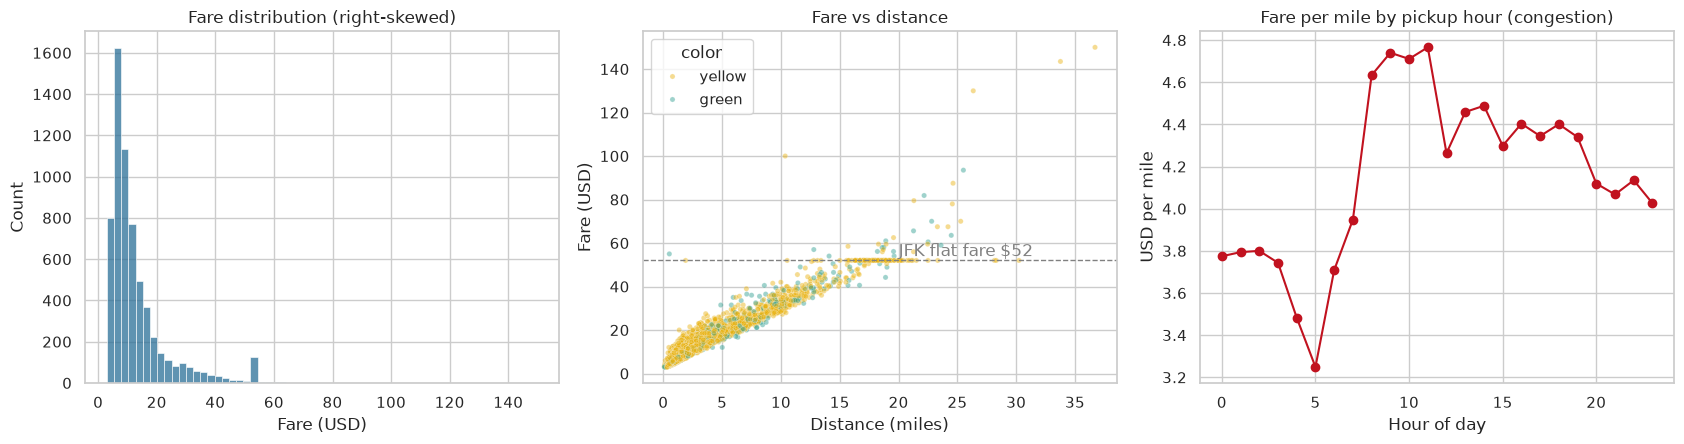

                 count   mean    std   min   25%    50%    75%     max
fare         6,348.000 13.042 11.231 3.000 6.500  9.500 15.000 150.000
distance     6,348.000  3.059  3.837 0.090 1.000  1.670  3.250  36.700
duration_min 6,348.000 14.518 11.600 1.000 6.667 11.000 18.604 107.667

Correlation of fare with distance: 0.961


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
sns.histplot(df["fare"], bins=60, ax=axes[0], color="#2a6f97")
axes[0].set(title="Fare distribution (right-skewed)", xlabel="Fare (USD)")
sample = df.sample(min(len(df), 5000), random_state=RANDOM_STATE)
sns.scatterplot(data=sample, x="distance", y="fare", hue="color", palette={"yellow": "#e9b10c", "green": "#2a9d8f"},
                alpha=.45, s=14, ax=axes[1])
axes[1].axhline(52, ls="--", c="grey", lw=1); axes[1].text(20, 54, "JFK flat fare $52", color="grey")
axes[1].set(title="Fare vs distance", xlabel="Distance (miles)", ylabel="Fare (USD)")
hourly = df.groupby("hour").agg(fare_per_mile=("fare", "sum"), miles=("distance", "sum"))
(hourly["fare_per_mile"] / hourly["miles"]).plot(marker="o", ax=axes[2], color="#c1121f")
axes[2].set(title="Fare per mile by pickup hour (congestion)", xlabel="Hour of day", ylabel="USD per mile")
savefig("01_eda_overview")

print(df[["fare", "distance", "duration_min"]].describe().T)
print("\nCorrelation of fare with distance:", round(df["fare"].corr(df["distance"]), 3))

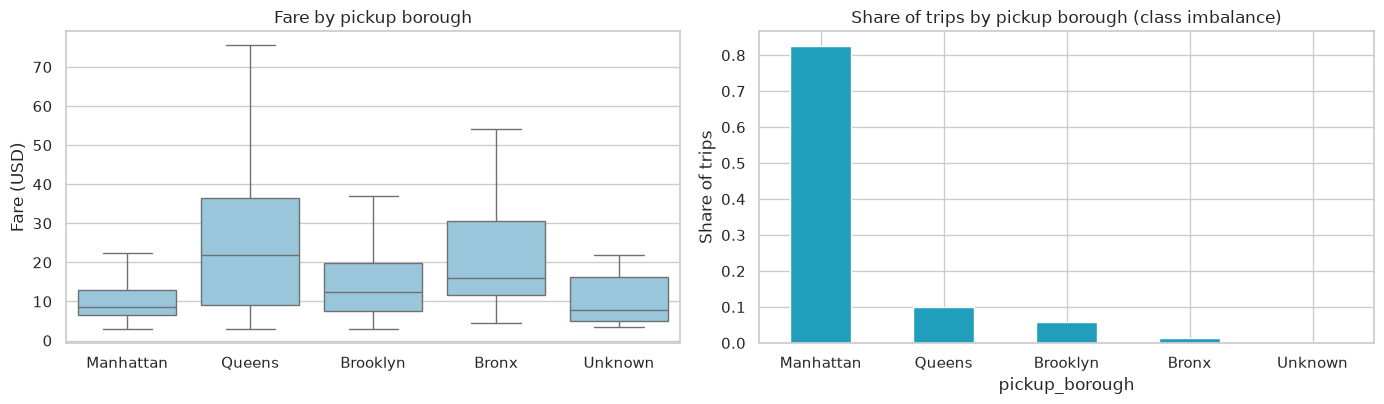

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
order = df["pickup_borough"].value_counts().index
sns.boxplot(data=df, x="pickup_borough", y="fare", order=order, ax=axes[0], showfliers=False, color="#8ecae6")
axes[0].set(title="Fare by pickup borough", xlabel="", ylabel="Fare (USD)")
counts = df["pickup_borough"].value_counts(normalize=True).reindex(order)
counts.plot.bar(ax=axes[1], color="#219ebc")
axes[1].set(title="Share of trips by pickup borough (class imbalance)", ylabel="Share of trips")
axes[1].tick_params(axis="x", rotation=0)
savefig("02_eda_borough")

### 1.5 Time-based train/test split

A random split would leak information across days. To mimic deployment (train on the past, predict
the future), the **last week of the month is held out** as the test set and never touched during tuning.

In [8]:
cutoff = pd.Timestamp(f"{df['pickup'].max():%Y-%m}-25")
train_df = df[df["pickup"] < cutoff].reset_index(drop=True)
test_df = df[df["pickup"] >= cutoff].reset_index(drop=True)
X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_test, y_test = test_df[FEATURES], test_df[TARGET]
print(f"Train: {len(train_df):,} trips before {cutoff.date()} | Test: {len(test_df):,} trips from {cutoff.date()}")

Train: 4,985 trips before 2019-03-25 | Test: 1,363 trips from 2019-03-25


### 1.6 Pre-processing pipeline and Deliverable-1 baselines

* **Linear models:** numeric features standardised; categorical features one-hot encoded
  (zones seen fewer than 20 times are grouped into an "infrequent" bucket).
* **Tree models:** same encoder, no scaling needed.

Baselines: (a) predict the mean fare, (b) the **official 2019 TLC rate card** applied to distance only
($2.50 + $2.50/mile, $52 JFK flat fare), (c) Ridge, Random Forest and Gradient Boosting with default
settings.

In [9]:
def make_preprocessor(scale):
    return ColumnTransformer([
        ("num", StandardScaler() if scale else "passthrough", NUMERIC),
        ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=20, sparse_output=False),
         CATEGORICAL),
    ])

def make_pipeline(model, scale=False):
    return Pipeline([("prep", make_preprocessor(scale)), ("model", model)])

class RateCardModel:
    '''Rule-based benchmark: 2019 TLC tariff using distance only (ignores time in traffic).'''
    def fit(self, X, y): return self
    def predict(self, X):
        fare = 2.5 + 2.5 * X["distance"].to_numpy()
        return np.where(X["jfk_manhattan"].to_numpy() == 1, 52.0, fare)

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = {"MAE": "neg_mean_absolute_error", "RMSE": "neg_root_mean_squared_error", "R2": "r2"}

baselines = {
    "Mean fare (Dummy)": make_pipeline(DummyRegressor()),
    "Ridge (default)": make_pipeline(Ridge(), scale=True),
    "Random Forest (default)": make_pipeline(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
    "Gradient Boosting (default)": make_pipeline(HistGradientBoostingRegressor(random_state=RANDOM_STATE)),
}
rows = []
rc = RateCardModel().predict(X_train)
rows.append({"model": "TLC rate card (rule)", "CV MAE": mean_absolute_error(y_train, rc),
             "CV RMSE": mean_squared_error(y_train, rc) ** .5, "CV R2": r2_score(y_train, rc)})
for name, pipe in baselines.items():
    s = cross_validate(pipe, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1)
    rows.append({"model": name, "CV MAE": -s["test_MAE"].mean(), "CV RMSE": -s["test_RMSE"].mean(),
                 "CV R2": s["test_R2"].mean()})
baseline_table = pd.DataFrame(rows).set_index("model")
baseline_table

,CV MAE,CV RMSE,CV R2
model,,,
TLC rate card (rule),2.889,4.446,0.849
Mean fare (Dummy),7.461,11.437,-0.000
Ridge (default),1.649,2.924,0.934
Random Forest (default),1.511,3.027,0.930
Gradient Boosting (default),1.506,3.150,0.923


## Part 2 — Hyperparameter Tuning

**Strategy.** All tuning uses **5-fold cross-validation on the training weeks only**; the hold-out week
is untouched until Part 3. The primary metric is **MAE** (mean absolute error, in dollars) because it is
directly interpretable for riders ("the quote is off by $X on average") and less dominated by a few
extreme trips than RMSE.

| Model | Search method | Hyperparameters searched |
|---|---|---|
| Ridge regression | `GridSearchCV` (exhaustive, 1-D) | `alpha` ∈ 10⁻³ … 10³ (13 values) |
| Random Forest | `RandomizedSearchCV`, 30 draws | `n_estimators`, `max_depth`, `min_samples_leaf`, `max_features` |
| Histogram Gradient Boosting | `RandomizedSearchCV`, 40 draws | `learning_rate`, `max_iter`, `max_leaf_nodes`, `min_samples_leaf`, `l2_regularization`, `loss` |

Randomized search is used for the tree ensembles because their search spaces are 4–6 dimensional; 30–40
random draws cover such spaces far more efficiently than a grid of the same cost (Bergstra & Bengio, 2012).

In [10]:
tuning = {}

t0 = time.time()
ridge_search = GridSearchCV(
    make_pipeline(Ridge(), scale=True),
    {"model__alpha": np.logspace(-3, 3, 13)},
    cv=cv, scoring="neg_mean_absolute_error", n_jobs=-1, return_train_score=True)
ridge_search.fit(X_train, y_train)
tuning["Ridge"] = (ridge_search, time.time() - t0)

t0 = time.time()
rf_search = RandomizedSearchCV(
    make_pipeline(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
    {"model__n_estimators": randint(100, 600),
     "model__max_depth": [None, 6, 10, 14, 20],
     "model__min_samples_leaf": randint(1, 20),
     "model__max_features": [1.0, 0.7, 0.5, 0.3, "sqrt"]},
    n_iter=30, cv=cv, scoring="neg_mean_absolute_error", n_jobs=-1,
    random_state=RANDOM_STATE, return_train_score=True)
rf_search.fit(X_train, y_train)
tuning["Random Forest"] = (rf_search, time.time() - t0)

t0 = time.time()
hgb_search = RandomizedSearchCV(
    make_pipeline(HistGradientBoostingRegressor(random_state=RANDOM_STATE)),
    {"model__learning_rate": loguniform(0.01, 0.3),
     "model__max_iter": randint(100, 800),
     "model__max_leaf_nodes": randint(8, 64),
     "model__min_samples_leaf": randint(5, 60),
     "model__l2_regularization": loguniform(1e-4, 10),
     "model__loss": ["squared_error", "absolute_error"]},
    n_iter=40, cv=cv, scoring="neg_mean_absolute_error", n_jobs=-1,
    random_state=RANDOM_STATE, return_train_score=True)
hgb_search.fit(X_train, y_train)
tuning["Gradient Boosting"] = (hgb_search, time.time() - t0)

default_mae = {"Ridge": "Ridge (default)", "Random Forest": "Random Forest (default)",
               "Gradient Boosting": "Gradient Boosting (default)"}
summary = []
for name, (search, secs) in tuning.items():
    best = search.best_index_
    summary.append({
        "model": name,
        "default CV MAE": baseline_table.loc[default_mae[name], "CV MAE"],
        "tuned CV MAE": -search.best_score_,
        "CV MAE std": search.cv_results_["std_test_score"][best],
        "train MAE": -search.cv_results_["mean_train_score"][best],
        "configs tried": len(search.cv_results_["params"]),
        "search time (s)": secs,
    })
tuning_table = pd.DataFrame(summary).set_index("model")
tuning_table["improvement"] = 1 - tuning_table["tuned CV MAE"] / tuning_table["default CV MAE"]
tuning_table

,default CV MAE,tuned CV MAE,CV MAE std,train MAE,configs tried,search time (s),improvement
model,,,,,,,
Ridge,1.649,1.627,0.055,1.593,13,1.533,0.014
Random Forest,1.511,1.485,0.056,0.805,30,135.183,0.017
Gradient Boosting,1.506,1.394,0.086,1.186,40,242.532,0.074


In [11]:
for name, (search, _) in tuning.items():
    params = {k.replace("model__", ""): (round(v, 4) if isinstance(v, float) else v)
              for k, v in search.best_params_.items()}
    print(f"{name:18s} best params: {params}")

Ridge              best params: {'alpha': np.float64(31.6228)}
Random Forest      best params: {'max_depth': 14, 'max_features': 0.7, 'min_samples_leaf': 1, 'n_estimators': 559}
Gradient Boosting  best params: {'l2_regularization': np.float64(0.4061), 'learning_rate': np.float64(0.0223), 'loss': 'absolute_error', 'max_iter': 492, 'max_leaf_nodes': 22, 'min_samples_leaf': 19}


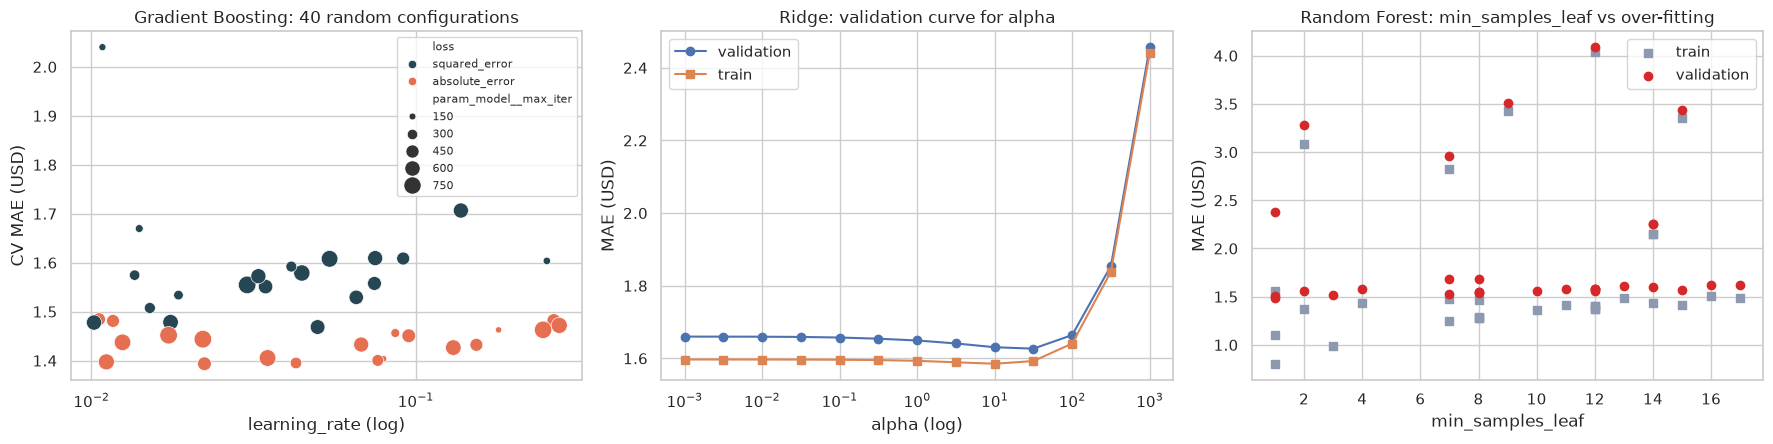

In [12]:
res = pd.DataFrame(hgb_search.cv_results_)
res["cv_mae"] = -res["mean_test_score"]
res["train_mae"] = -res["mean_train_score"]
res["lr"] = res["param_model__learning_rate"].astype(float)
res["loss"] = res["param_model__loss"].astype(str)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.6))
sns.scatterplot(data=res, x="lr", y="cv_mae", hue="loss", size=res["param_model__max_iter"].astype(int),
                sizes=(20, 160), ax=axes[0], palette=["#264653", "#e76f51"])
axes[0].set(xscale="log", title="Gradient Boosting: 40 random configurations",
            xlabel="learning_rate (log)", ylabel="CV MAE (USD)")
axes[0].legend(fontsize=8, loc="upper right")

ra = pd.DataFrame(ridge_search.cv_results_)
axes[1].plot(ra["param_model__alpha"].astype(float), -ra["mean_test_score"], marker="o", label="validation")
axes[1].plot(ra["param_model__alpha"].astype(float), -ra["mean_train_score"], marker="s", label="train")
axes[1].set(xscale="log", title="Ridge: validation curve for alpha", xlabel="alpha (log)", ylabel="MAE (USD)")
axes[1].legend()

rr = pd.DataFrame(rf_search.cv_results_)
rr["leaf"] = rr["param_model__min_samples_leaf"].astype(int)
axes[2].scatter(rr["leaf"], -rr["mean_train_score"], label="train", marker="s", color="#8d99ae")
axes[2].scatter(rr["leaf"], -rr["mean_test_score"], label="validation", color="#d62828")
axes[2].set(title="Random Forest: min_samples_leaf vs over-fitting", xlabel="min_samples_leaf", ylabel="MAE (USD)")
axes[2].legend()
savefig("03_tuning")

## Part 3 — Final Model Evaluation

The best configuration from each search is refit on all training weeks (done automatically by
`refit=True`) and evaluated **once** on the hold-out week. Metrics:

* **MAE** — average dollar error of a quote (primary).
* **RMSE** — penalises large misses (e.g. a $30 error on an airport trip).
* **R²** — share of fare variance explained.
* **MAPE** — relative error, what a rider perceives on short trips.
* **Within $2 / within 10%** — business-facing accuracy of a quote.

In [13]:
def metrics(y, p):
    return {"MAE": mean_absolute_error(y, p), "RMSE": mean_squared_error(y, p) ** .5, "R2": r2_score(y, p),
            "MAPE": np.mean(np.abs(y - p) / y),
            "within $2": np.mean(np.abs(y - p) <= 2), "within 10%": np.mean(np.abs(y - p) / y <= .10)}

final_models = {"Mean fare (Dummy)": baselines["Mean fare (Dummy)"].fit(X_train, y_train),
                "TLC rate card (rule)": RateCardModel()}
final_models.update({f"{n} (tuned)": s.best_estimator_ for n, (s, _) in tuning.items()})
preds = {name: m.predict(X_test) for name, m in final_models.items()}
test_table = pd.DataFrame({name: metrics(y_test, p) for name, p in preds.items()}).T
test_table.sort_values("MAE")

,MAE,RMSE,R2,MAPE,within $2,within 10%
Gradient Boosting (tuned),1.257,2.283,0.951,0.103,0.833,0.575
Random Forest (tuned),1.371,2.329,0.949,0.115,0.801,0.539
Ridge (tuned),1.553,2.644,0.935,0.141,0.784,0.483
TLC rate card (rule),2.760,3.907,0.858,0.223,0.504,0.167
Mean fare (Dummy),7.168,10.356,-0.001,0.725,0.141,0.102


In [14]:
best_name = test_table.drop(["Mean fare (Dummy)", "TLC rate card (rule)"])["MAE"].idxmin()
best_model = final_models[best_name]
p_best = preds[best_name]
resid = y_test - p_best
print(f"Selected model: {best_name}")

# bootstrap 95% confidence interval for the hold-out MAE
rng = np.random.default_rng(RANDOM_STATE)
abs_err = np.abs(resid.to_numpy())
boot = [abs_err[rng.integers(0, len(abs_err), len(abs_err))].mean() for _ in range(2000)]
print(f"Hold-out MAE = ${abs_err.mean():.2f} (95% bootstrap CI ${np.percentile(boot, 2.5):.2f}–${np.percentile(boot, 97.5):.2f})")
rc_err = np.abs(y_test - preds["TLC rate card (rule)"]).mean()
print(f"Error reduction vs TLC rate-card rule: {1 - abs_err.mean() / rc_err:.1%}")

Selected model: Gradient Boosting (tuned)
Hold-out MAE = $1.26 (95% bootstrap CI $1.17–$1.36)
Error reduction vs TLC rate-card rule: 54.4%


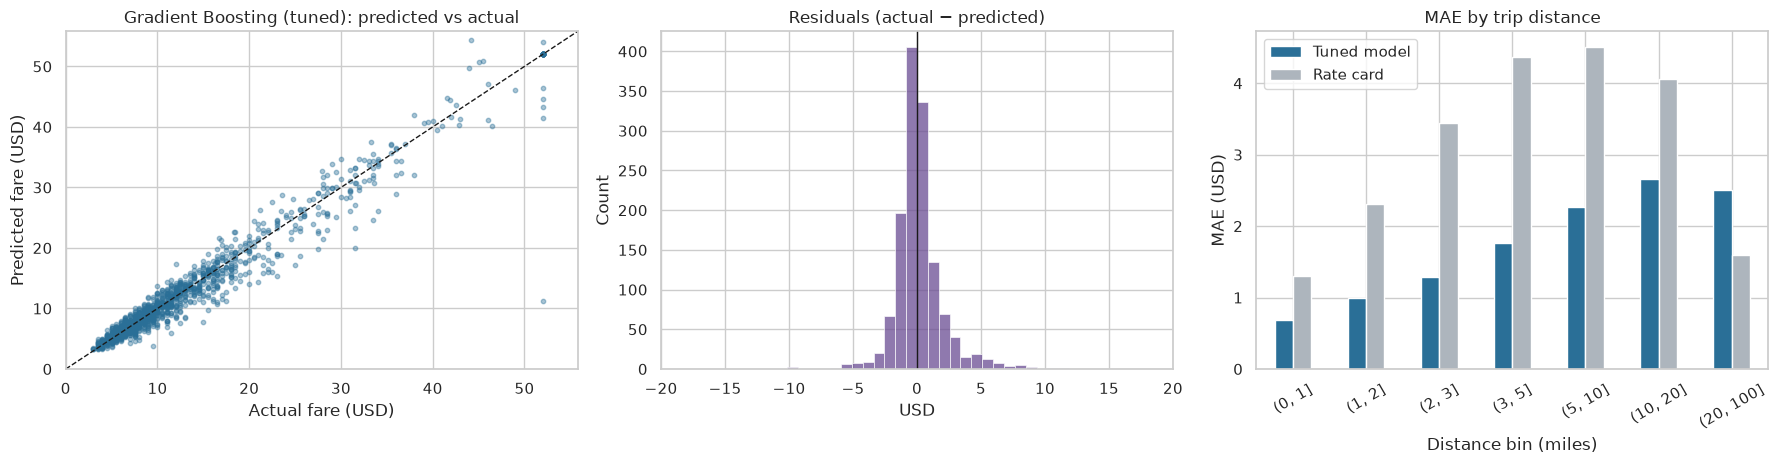

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
lim = [0, np.percentile(y_test, 99.5) * 1.05]
axes[0].scatter(y_test, p_best, s=10, alpha=.4, color="#2a6f97")
axes[0].plot(lim, lim, "k--", lw=1)
axes[0].set(xlim=lim, ylim=lim, title=f"{best_name}: predicted vs actual", xlabel="Actual fare (USD)",
            ylabel="Predicted fare (USD)")
sns.histplot(resid, bins=60, ax=axes[1], color="#6a4c93")
axes[1].axvline(0, c="k", lw=1)
axes[1].set(title="Residuals (actual − predicted)", xlabel="USD", xlim=(-20, 20))
bins = pd.cut(test_df["distance"], [0, 1, 2, 3, 5, 10, 20, 100])
err_dist = pd.DataFrame({"bin": bins, "Tuned model": np.abs(resid), "Rate card": np.abs(y_test - preds["TLC rate card (rule)"])})
err_dist.groupby("bin", observed=True).mean().plot.bar(ax=axes[2], color=["#2a6f97", "#adb5bd"])
axes[2].set(title="MAE by trip distance", xlabel="Distance bin (miles)", ylabel="MAE (USD)")
axes[2].tick_params(axis="x", rotation=30)
savefig("04_final_evaluation")

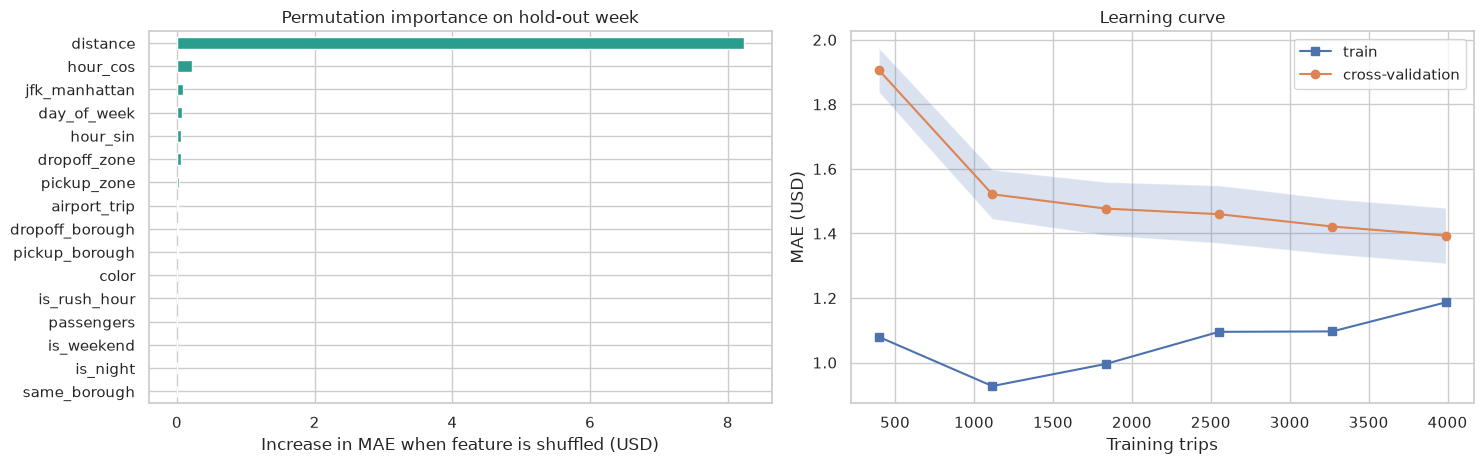

distance           8.228
hour_cos           0.215
jfk_manhattan      0.093
day_of_week        0.074
hour_sin           0.064
dropoff_zone       0.057
pickup_zone        0.027
airport_trip       0.020
dropoff_borough    0.012
pickup_borough     0.010
color              0.004
is_rush_hour       0.004
passengers         0.000
is_night           0.000
is_weekend         0.000
same_borough      -0.001
dtype: float64


In [16]:
pi = permutation_importance(best_model, X_test, y_test, scoring="neg_mean_absolute_error",
                            n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=FEATURES).sort_values()
sizes, tr, va = learning_curve(best_model, X_train, y_train, cv=cv, scoring="neg_mean_absolute_error",
                               train_sizes=np.linspace(.1, 1, 6), n_jobs=-1)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
imp.plot.barh(ax=axes[0], color="#2a9d8f")
axes[0].set(title="Permutation importance on hold-out week", xlabel="Increase in MAE when feature is shuffled (USD)")
axes[1].plot(sizes, -tr.mean(1), "s-", label="train")
axes[1].plot(sizes, -va.mean(1), "o-", label="cross-validation")
axes[1].fill_between(sizes, -va.mean(1) - va.std(1), -va.mean(1) + va.std(1), alpha=.2)
axes[1].set(title="Learning curve", xlabel="Training trips", ylabel="MAE (USD)")
axes[1].legend()
savefig("05_importance_learning_curve")
print(imp.sort_values(ascending=False).round(3))

### Error analysis — where does the model fail?
The largest misses are inspected to understand whether they are model failures or data problems.

In [17]:
worst = test_df.assign(predicted=p_best, error=resid).reindex(resid.abs().sort_values(ascending=False).index)
worst[["pickup", "distance", "duration_min", "pickup_zone", "dropoff_zone", "fare", "predicted", "error"]].head(10)

,pickup,distance,duration_min,pickup_zone,dropoff_zone,fare,predicted,error
375,2019-03-29 16:48:18,1.890,8.217,Long Island City/Hunters Point,Murray Hill,52.000,11.253,40.747
503,2019-03-29 22:29:40,19.200,24.800,JFK Airport,Unknown,84.000,56.894,27.106
1247,2019-03-28 15:55:12,4.880,51.783,Fort Greene,Brownsville,31.500,19.950,11.550
461,2019-03-25 16:04:47,13.110,44.067,South Jamaica,Flushing Meadows-Corona Park,52.000,41.444,10.556
1197,2019-03-30 22:13:58,18.890,33.717,Douglaston,Spuyten Duyvil/Kingsbridge,44.200,54.387,-10.187
1237,2019-03-25 18:54:47,22.510,44.600,Morrisania/Melrose,Baisley Park,60.520,70.628,-10.108
1305,2019-03-27 11:27:02,6.620,47.333,Mott Haven/Port Morris,Midtown North,33.540,24.630,8.910
866,2019-03-29 22:23:08,15.140,29.483,Jamaica,Upper West Side North,52.000,43.259,8.741
401,2019-03-30 22:02:43,6.790,47.083,Greenwich Village South,Upper West Side South,31.500,23.282,8.218
36,2019-03-29 10:25:21,6.710,49.100,Times Sq/Theatre District,Williamsburg (North Side),34.000,26.045,7.955


## Part 4 — Ethical Evaluation: Is the model equally accurate for everyone?

A quote that is systematically too **low** in some neighbourhoods leads to "surprise" charges for
those riders; one that is systematically too **high** may push them to other modes of transport.
Neither borough nor taxi colour is a protected attribute, but in NYC both are strongly correlated with
income and race, so geographic error differences are a **proxy-discrimination risk**.

The audit below compares hold-out error and *bias* (mean of actual − predicted; positive = model
under-quotes) across groups. Payment type is not a model input, but it is audited because cash users
are more likely to be unbanked / lower-income riders.

In [18]:
audit = test_df.assign(pred=p_best, abs_err=np.abs(resid), bias=resid, ape=np.abs(resid) / test_df["fare"])

def group_report(col):
    g = audit.groupby(col).agg(trips=("fare", "size"), mean_fare=("fare", "mean"), MAE=("abs_err", "mean"),
                               MAPE=("ape", "mean"), bias=("bias", "mean"))
    g["MAE ratio vs overall"] = g["MAE"] / audit["abs_err"].mean()
    return g[g["trips"] >= 10].sort_values("trips", ascending=False)

for col in ["pickup_borough", "color", "payment"]:
    print(f"\n=== by {col} ===")
    display(group_report(col))


=== by pickup_borough ===


,trips,mean_fare,MAE,MAPE,bias,MAE ratio vs overall
pickup_borough,,,,,,
Manhattan,1123,10.916,1.126,0.106,0.194,0.895
Queens,146,24.334,1.856,0.080,0.412,1.476
Brooklyn,71,16.152,1.545,0.094,0.084,1.229
Bronx,21,23.006,3.071,0.163,-1.053,2.443



=== by color ===


,trips,mean_fare,MAE,MAPE,bias,MAE ratio vs overall
color,,,,,,
yellow,1155,12.777,1.234,0.103,0.269,0.981
green,208,13.006,1.387,0.103,-0.257,1.104



=== by payment ===


,trips,mean_fare,MAE,MAPE,bias,MAE ratio vs overall
payment,,,,,,
credit card,965,13.339,1.269,0.102,0.119,1.010
cash,391,11.448,1.232,0.108,0.367,0.980


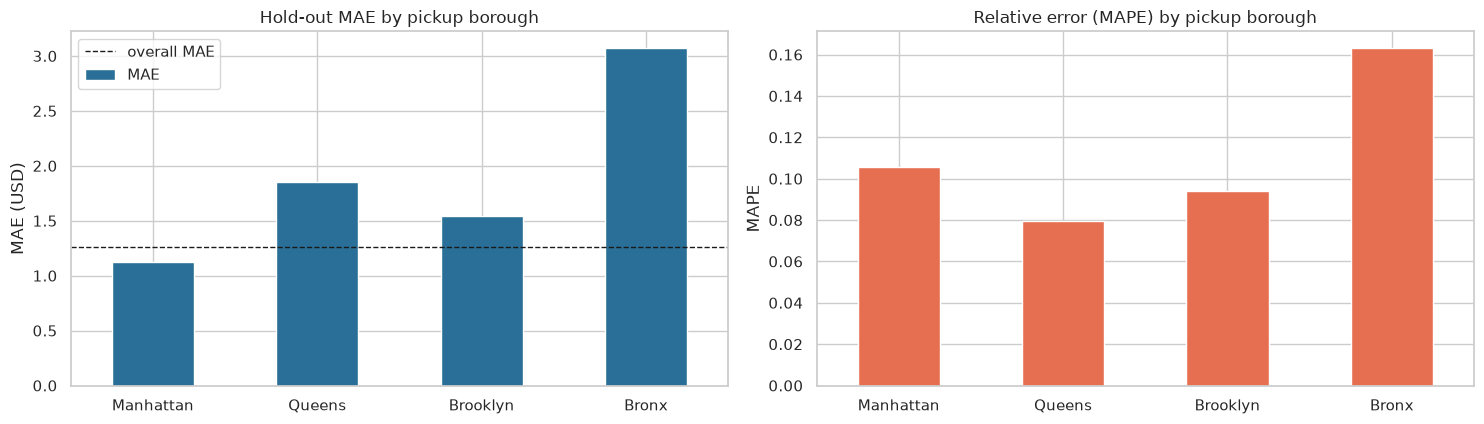

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.4))
gb = group_report("pickup_borough")
gb[["MAE"]].plot.bar(ax=axes[0], color="#2a6f97", legend=False)
axes[0].axhline(audit["abs_err"].mean(), ls="--", c="k", lw=1, label="overall MAE")
axes[0].set(title="Hold-out MAE by pickup borough", ylabel="MAE (USD)", xlabel="")
axes[0].legend(); axes[0].tick_params(axis="x", rotation=0)
gb["MAPE"].plot.bar(ax=axes[1], color="#e76f51")
axes[1].set(title="Relative error (MAPE) by pickup borough", ylabel="MAPE", xlabel="")
axes[1].tick_params(axis="x", rotation=0)
savefig("06_fairness_audit")

## Part 5 — Real-World Application: Upfront Fare Quotes with a Price Range

Riders trust a **range** more than a single number when the range reliably contains the final price.
Two quantile gradient-boosting models (10th and 90th percentile), using the tuned hyper-parameters,
produce an 80% prediction interval. We then simulate the rider experience on the hold-out week.

In [20]:
best_hgb = {k.replace("model__", ""): v for k, v in hgb_search.best_params_.items() if k != "model__loss"}
quantile_models = {}
for q in (0.1, 0.9):
    quantile_models[q] = make_pipeline(HistGradientBoostingRegressor(loss="quantile", quantile=q,
                                                                     random_state=RANDOM_STATE, **best_hgb))
    quantile_models[q].fit(X_train, y_train)
lo, hi = quantile_models[0.1].predict(X_test), quantile_models[0.9].predict(X_test)
lo, hi = np.minimum(lo, p_best), np.maximum(hi, p_best)
inside = (y_test >= lo) & (y_test <= hi)
print(f"80% interval empirical coverage on hold-out week: {inside.mean():.1%}")
print(f"Median interval width: ${np.median(hi - lo):.2f}")

sim = test_df.assign(quote=p_best, low=lo, high=hi, inside=inside)
sim["surprise_over_$5"] = (sim["fare"] - sim["quote"]) > 5
print(f"Trips where rider pays > $5 more than the point quote: {sim['surprise_over_$5'].mean():.1%}")
print(f"Same for TLC rate-card quote: {((y_test - preds['TLC rate card (rule)']) > 5).mean():.1%}")
display(sim.groupby("pickup_borough").agg(trips=("fare", "size"), coverage=("inside", "mean"),
                                          surprise_over_5=("surprise_over_$5", "mean")).query("trips >= 10"))

80% interval empirical coverage on hold-out week: 76.7%
Median interval width: $3.12
Trips where rider pays > $5 more than the point quote: 2.7%
Same for TLC rate-card quote: 14.2%


,trips,coverage,surprise_over_5
pickup_borough,,,
Bronx,21,0.619,0.048
Brooklyn,71,0.845,0.028
Manhattan,1123,0.765,0.023
Queens,146,0.760,0.055


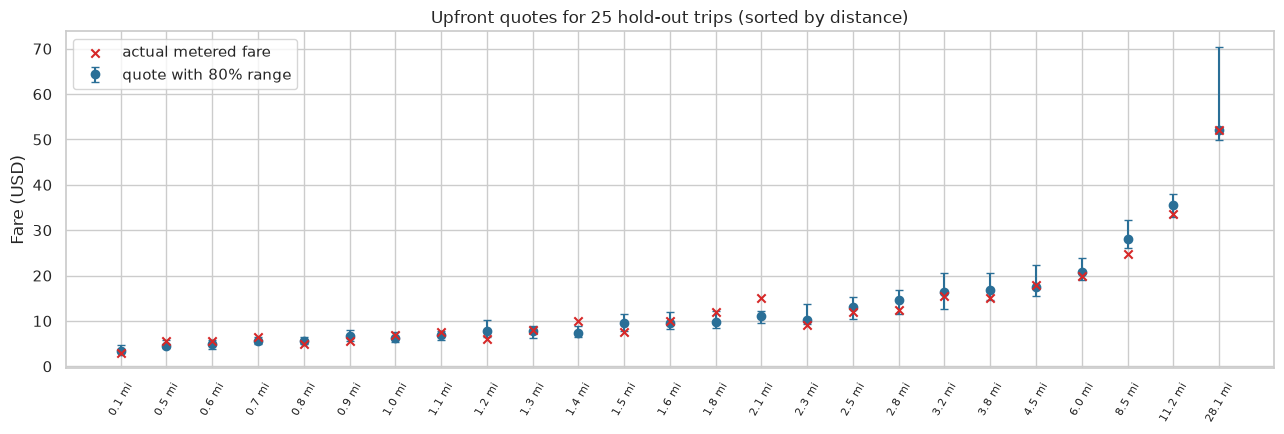

In [21]:
examples = sim.sort_values("distance").iloc[np.linspace(0, len(sim) - 1, 25).astype(int)]
fig, ax = plt.subplots(figsize=(13, 4.5))
x = np.arange(len(examples))
ax.errorbar(x, examples["quote"], yerr=[examples["quote"] - examples["low"], examples["high"] - examples["quote"]],
            fmt="o", color="#2a6f97", capsize=3, label="quote with 80% range")
ax.scatter(x, examples["fare"], marker="x", color="#d62828", zorder=3, label="actual metered fare")
ax.set_xticks(x, [f"{d:.1f} mi" for d in examples["distance"]], rotation=60, fontsize=8)
ax.set(title="Upfront quotes for 25 hold-out trips (sorted by distance)", ylabel="Fare (USD)")
ax.legend()
savefig("07_quote_ranges")

### Deployment sketch — how the model would be used

```python
quote = best_model.predict(new_trip_features)       # point estimate shown in the app
low, high = q10.predict(...), q90.predict(...)       # "Estimated fare $18–$24"
```

1. Rider enters pickup & destination → routing API returns estimated distance.
2. Feature pipeline builds the same features as training (identical `Pipeline` object, saved with `joblib`).
3. Model returns quote + range in milliseconds; the meter still determines the final fare.
4. Monitoring: weekly MAE, coverage and per-borough bias on completed trips; retrain monthly or when
   the TLC tariff changes (Dec 2022 fare increase; congestion-pricing surcharge from Jan 2025).

In [22]:
import joblib
joblib.dump({"point": best_model, "q10": quantile_models[0.1], "q90": quantile_models[0.9],
             "features": FEATURES}, "fare_quote_model.joblib")

new_trip = add_features(pd.DataFrame([{
    "pickup": pd.Timestamp("2019-03-29 17:30"), "passengers": 1, "distance": 3.2, "color": "yellow",
    "pickup_zone": "Midtown Center", "dropoff_zone": "East Village",
    "pickup_borough": "Manhattan", "dropoff_borough": "Manhattan"}]))[FEATURES]
q, l, h = (m.predict(new_trip)[0] for m in (best_model, quantile_models[0.1], quantile_models[0.9]))
print(f"Friday 5:30 pm, Midtown -> East Village, 3.2 mi: estimated fare ${q:.2f} (range ${min(l, q):.2f}–${max(h, q):.2f})")

Friday 5:30 pm, Midtown -> East Village, 3.2 mi: estimated fare $15.42 (range $12.67–$18.80)


## Part 6 — Final Thoughts and Conclusion

See `REPORT.md` for the written discussion (hyperparameter tuning, final evaluation, ethics,
real-world application, conclusion). The final summary tables are printed below for reference.

In [23]:
print("Hyperparameter tuning (5-fold CV on training weeks):")
display(tuning_table.round(3))
print("Hold-out week performance:")
display(test_table.sort_values("MAE").round(3))

Hyperparameter tuning (5-fold CV on training weeks):


,default CV MAE,tuned CV MAE,CV MAE std,train MAE,configs tried,search time (s),improvement
model,,,,,,,
Ridge,1.649,1.627,0.055,1.593,13,1.533,0.014
Random Forest,1.511,1.485,0.056,0.805,30,135.183,0.017
Gradient Boosting,1.506,1.394,0.086,1.186,40,242.532,0.074


Hold-out week performance:


,MAE,RMSE,R2,MAPE,within $2,within 10%
Gradient Boosting (tuned),1.257,2.283,0.951,0.103,0.833,0.575
Random Forest (tuned),1.371,2.329,0.949,0.115,0.801,0.539
Ridge (tuned),1.553,2.644,0.935,0.141,0.784,0.483
TLC rate card (rule),2.760,3.907,0.858,0.223,0.504,0.167
Mean fare (Dummy),7.168,10.356,-0.001,0.725,0.141,0.102
